# Data Mining 2026  — Project Notebook

**Course:** Data Mining  
**Project track:** ☒ Standard Analysis ☐ Research-Oriented  
**Group Number:** 16 </br>
**Group members:**  
- Giancarlo Marchesini  
- Himan Kalita 
- Kris Kraack


**Dataset:**  
**Initial task description (Module 1 perspective):**
This notebook demonstrates how to cluster daily bike sharing data, i.e., apply clustering to discover structure in bike-sharing demand patterns, using K-Means (Method 1) and density-based clustering algorithm DBSCAN (Method 2). 

Method 1: K-Means/K-Means++
After loading and exporing the datasets. We first perform feature engineering and do a gridsearch to find optimal hyperparameters. The goal is to identify daily weather and usage clusters.

Method 2: DBSCAN
Again, we perform feature engineering and standardization, explore the data using a k‑distance graph and t‑SNE, and then apply DBSCAN. The goal is to identify dense behavioural patterns (e.g., high-demand days, low-demand days) and detect noise points that may correspond to unusual events.


## 0. Reproducibility and Setup

In [1]:
import sys
print(sys.version)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN



RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

3.11.10 | packaged by conda-forge | (main, Oct 16 2024, 01:17:14) [MSC v.1941 64 bit (AMD64)]


## 1. Dataset Description and Loading

### 1.1 Dataset Overview

- Dataset: Bike Sharing Dataset (2011–2012)
- Reference: Fanaee-T, H. (2013). Bike Sharing [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5W894.
- Source: https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset
- Number of instances: 
    - 'hour.csv' : 17379;
    - 'day.csv' : 731.
- Number of features / entities: 
    - 'hour.csv' : 17;
    - 'day.csv' : 16.
- Missing values: The dataset doesn't have missing values.
- Basic statistics: See section below.


**Dataset characteristics** </br> 
Both hour.csv and day.csv have the following fields, except hr which is not available in day.csv
- instant: record index
- dteday : date
- season : season (1:springer, 2:summer, 3:fall, 4:winter)
- yr : year (0: 2011, 1:2012)
- mnth : month ( 1 to 12)
- hr : hour (0 to 23)
- holiday : weather day is holiday or not (extracted from http://dchr.dc.gov/page/holiday-schedule)
- weekday : day of the week
- workingday : if day is neither weekend nor holiday is 1, otherwise is 0.
+ weathersit : 
    - 1: Clear, Few clouds, Partly cloudy, Partly cloudy
    - 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
    - 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
    - 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog
- temp : Normalized temperature in Celsius. The values are divided to 41 (max)
- atemp: Normalized feeling temperature in Celsius. The values are divided to 50 (max)
- hum: Normalized humidity. The values are divided to 100 (max)
- windspeed: Normalized wind speed. The values are divided to 67 (max)
- casual: count of casual users
- registered: count of registered users
- cnt: count of total rental bikes including both casual and registered
	

In [2]:
# Load dataset
data_day  = pd.read_csv('data/day.csv')  # day csv file
data_hour = pd.read_csv('data/hour.csv') # hour csv file

# Print dataset(s) shapes (r,c)
print(f"day dataset - shape: {data_day.shape}") #day
print(f"hour dataset - shape: {data_hour.shape}") #hour

# Print missing values (NaNs)
print("day dataset - NaNs:", data_day.isnull().sum().sum()) 
print("hour dataset - NaNs:", data_hour.isnull().sum().sum())

# Inspect 
#data_hour.head(5)
data_day.head(5)

day dataset - shape: (731, 16)
hour dataset - shape: (17379, 17)
day dataset - NaNs: 0
hour dataset - NaNs: 0


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


### Exploratory Data Analysis

#### Basic statistics

In [3]:
# Basic statistics: Day
day_stats = (
    data_day.select_dtypes(include='number')
            .describe()
            .T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
            .round(3)
)
print("Basic statistics: Day:")
display(day_stats)

# Basic statistics: hour
hour_stats = (
    data_hour.select_dtypes(include='number')
             .describe()
             .T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
             .round(3)
)
print("Basic statistics: Hour")
display(hour_stats)

Basic statistics: Day:


,count,mean,std,min,25%,50%,75%,max
instant,731.0,366.000,211.166,1.000,183.500,366.000,548.500,731.000
season,731.0,2.497,1.111,1.000,2.000,3.000,3.000,4.000
yr,731.0,0.501,0.500,0.000,0.000,1.000,1.000,1.000
mnth,731.0,6.520,3.452,1.000,4.000,7.000,10.000,12.000
holiday,731.0,0.029,0.167,0.000,0.000,0.000,0.000,1.000
weekday,731.0,2.997,2.005,0.000,1.000,3.000,5.000,6.000
workingday,731.0,0.684,0.465,0.000,0.000,1.000,1.000,1.000
weathersit,731.0,1.395,0.545,1.000,1.000,1.000,2.000,3.000
temp,731.0,0.495,0.183,0.059,0.337,0.498,0.655,0.862
atemp,731.0,0.474,0.163,0.079,0.338,0.487,0.609,0.841


Basic statistics: Hour


,count,mean,std,min,25%,50%,75%,max
instant,17379.0,8690.000,5017.029,1.00,4345.500,8690.000,13034.500,17379.000
season,17379.0,2.502,1.107,1.00,2.000,3.000,3.000,4.000
yr,17379.0,0.503,0.500,0.00,0.000,1.000,1.000,1.000
mnth,17379.0,6.538,3.439,1.00,4.000,7.000,10.000,12.000
hr,17379.0,11.547,6.914,0.00,6.000,12.000,18.000,23.000
holiday,17379.0,0.029,0.167,0.00,0.000,0.000,0.000,1.000
weekday,17379.0,3.004,2.006,0.00,1.000,3.000,5.000,6.000
workingday,17379.0,0.683,0.465,0.00,0.000,1.000,1.000,1.000
weathersit,17379.0,1.425,0.639,1.00,1.000,1.000,2.000,4.000
temp,17379.0,0.497,0.193,0.02,0.340,0.500,0.660,1.000


#### Correlation Heatmap

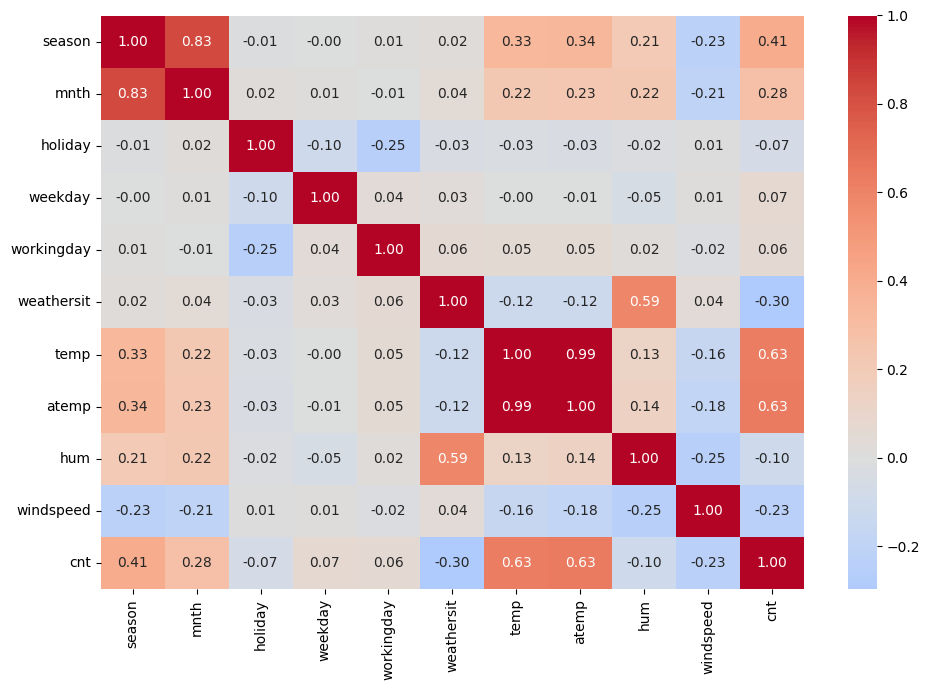

In [12]:
# Correlation heatmap using day data
# Select columns
columns = ['season', 'mnth', 'holiday', 'weekday', 'workingday',
             'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt']

# Plot correlation heatmap
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(data_day[columns].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.tight_layout()
plt.show()

#### Distributions

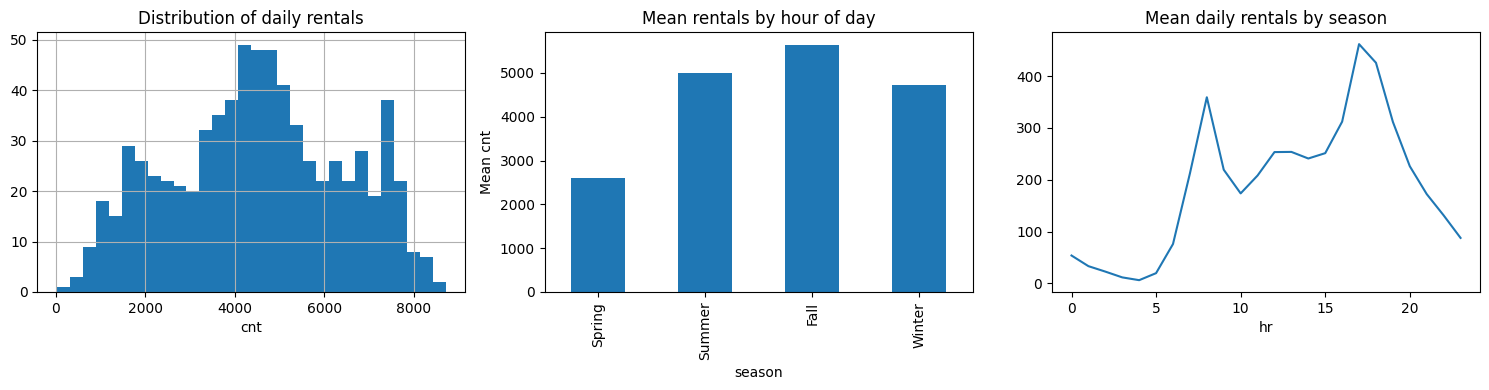

In [13]:
# Plot distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# daily rentals
data_day['cnt'].hist(ax=axes[0], bins=30)
axes[0].set_title('Distribution of daily rentals')
axes[0].set_xlabel('cnt')

# daily rentals (hour)
data_hour.groupby('hr')['cnt'].mean().plot(ax=axes[2])
axes[1].set_title('Mean rentals by hour of day')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Mean cnt')

# Seasons (mean)
season_labels = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
data_day.groupby('season')['cnt'].mean().rename(season_labels).plot(
    kind='bar', ax=axes[1])
axes[2].set_title('Mean daily rentals by season')

# Plot
plt.tight_layout()
plt.show()

#### Density

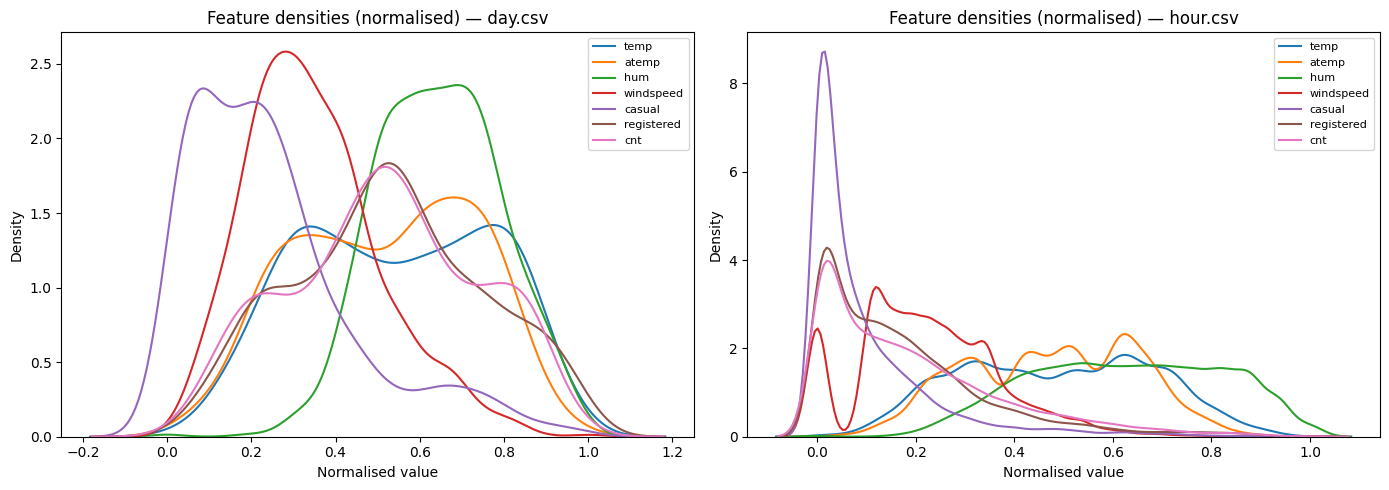

In [14]:
# KDE Density plots for selected continuous entries  (normalised)
columns_of_int  = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']

# Plot Density
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# day
for col in columns_of_int:
    vals = data_day[col]
    sns.kdeplot((vals - vals.min()) / (vals.max() - vals.min()),
                ax=axes[0], label=col, fill=False)
axes[0].set_title('Feature densities (normalised) — day.csv')
axes[0].set_xlabel('Normalised value')
axes[0].legend(fontsize=8)

# hour
for col in columns_of_int:
    vals = data_hour[col]
    sns.kdeplot((vals - vals.min()) / (vals.max() - vals.min()),
                ax=axes[1], label=col, fill=False)
axes[1].set_title('Feature densities (normalised) — hour.csv')
axes[1].set_xlabel('Normalised value')
axes[1].legend(fontsize=8)


plt.tight_layout()
plt.show()


## 2. Module 1 — Vector-Space Analysis

#### Feature engineering
Selected based on the correlation heatmap and the task definition

In [15]:
# Define the features for clustering: Selected based on the correlation heatmap 
features = ['temp', 'hum', 'windspeed', 'weathersit', 'season', 'workingday', 'cnt']

### 2.1 Vector Representation

**Feature vector:** Each day is represented by 7 features selected based on the correlation heatmap and task defintion.

| Feature | Type | Intuition |
|---|---|---|
| `temp` | continuous (normalised) | Strong positive correlation with `cnt` |
| `hum` | continuous (normalised) | Moderate negative correlation with `cnt` |
| `windspeed` | continuous (normalised) | Mild negative effect on ridership |
| `weathersit` | ordinal (1–4) | Captures weather severity |
| `season` | ordinal (1–4) | Seasonal demand variation |
| `workingday` | binary (0/1) | Commuter vs leisure usage patters |
| `cnt` | continuous (count) | Total demand: key signal |

**Preprocessing:** All features are standardised to zero mean and unit variance (`StandardScaler`) so that features with different scales contribute equally to the Euclidean distance.

**Distance measure:** Euclidean distance (default for K-Means).

In [16]:
# Construct vector representation
X = StandardScaler().fit_transform(data_day[features])  # Replace with actual feature matrix (standardised to zero mean and unit variance =  features with different scales contribute equally the Euclidean distance)

# Print shape
print(f"Feature matrix shape: {X.shape}") 

# Distance measure: We use euclidean distance (default for K-Means)

Feature matrix shape: (731, 7)


### 2.2 Clustering Method

### Method 1: K-Means/K-Means++

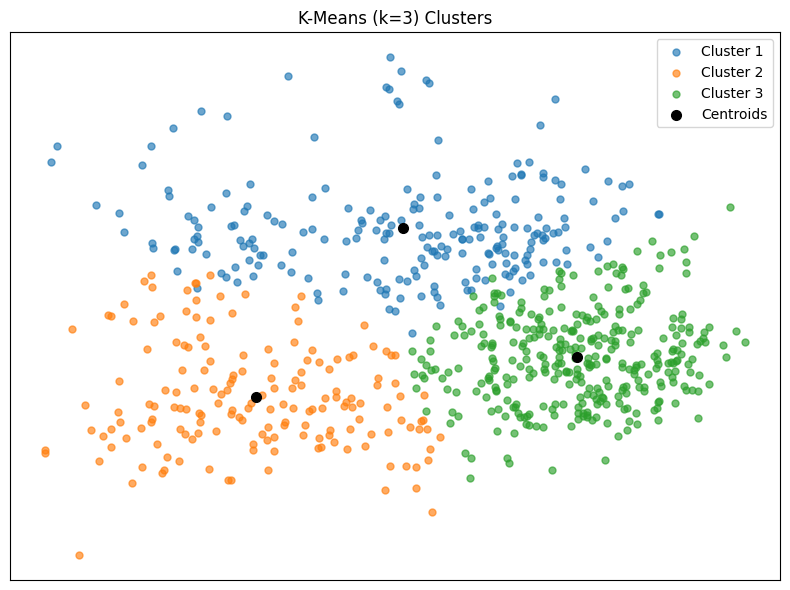

          temp    hum  windspeed  weathersit  season  workingday       cnt
cluster                                                                   
1        0.472  0.768      0.192       2.086   2.600       0.718  3764.468
2        0.308  0.498      0.236       1.170   1.345       0.637  2898.292
3        0.605  0.603      0.166       1.062   3.009       0.685  5790.847


In [17]:
# Implement clustering algorithm here: Method 1 (K-means): Manual without any parameter tuning
# Inititilze K and setup K-means (scikit learn) 
K = 3
kmeans = KMeans(n_clusters=K, random_state=RANDOM_SEED, n_init=35)
labels = kmeans.fit_predict(X)

# Using PCA for 2D plots
pca = PCA(n_components=2, random_state=RANDOM_SEED).fit_transform(X)
cents = PCA(n_components=2, random_state=RANDOM_SEED).fit(X).transform(kmeans.cluster_centers_)

# Plots clusters
fig, ax = plt.subplots(figsize=(8, 6))
for c in range(K):
    ax.scatter(*pca[labels == c].T, s=25, alpha=0.65, label=f'Cluster {c+1}')
ax.scatter(*cents.T, s=49, marker='o', c='black', zorder=5, label='Centroids')
ax.set(title=f'K-Means (k={K}) Clusters',)
ax.set_xticks([]); ax.set_yticks([])
ax.legend(); plt.tight_layout(); plt.show()

# Print cluster profiles (mean values of selected features) 
print(data_day[features].assign(cluster=labels+1).groupby('cluster').mean().round(3))

#### Parameter search

In [18]:
# grid search over K-Means & K-Means++ hyperparameters: Using silhouette as evaluation method
# References:
# https://stackoverflow.com/questions/34611038/grid-search-for-hyperparameter-evaluation-of-clustering-in-scikit-learn
# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.ParameterGrid.html#
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html
# https://farshadabdulazeez.medium.com/understanding-silhouette-score-in-clustering-8aedc06ce9c4
h_params = {
    'n_clusters': range(2, 10),
    'init': ['k-means++', 'random'],
    'n_init': [10]
}

# Gridsearch 
r = []
for p in ParameterGrid(h_params):
    kmeans = KMeans(random_state=RANDOM_SEED, **p)
    labels_k = kmeans.fit_predict(X)
    r.append({
        'k': p['n_clusters'],
        'init': p['init'],
        'silhouette': silhouette_score(X, labels_k),
        'inertia': kmeans.inertia_
    })

# Generate df with grid results 
grid_results = pd.DataFrame(r).sort_values(
    ['silhouette', 'inertia'],
    ascending=[False, True]
).reset_index(drop=True)

# show results
display(grid_results)

# Print best
print(f"Best: k={int(grid_results.loc[0, 'k'])}, method='{grid_results.loc[0, 'init']}', silhouette={float(grid_results.loc[0, 'silhouette']):.4f}")

,k,init,silhouette,inertia
0,2,k-means++,0.244613,3956.964456
1,2,random,0.244187,3956.969263
2,8,k-means++,0.242119,2107.353340
3,8,random,0.241977,2106.821046
4,9,k-means++,0.241298,1971.180281
5,9,random,0.239441,1972.560751
6,6,random,0.227104,2429.992502
7,3,random,0.226541,3280.320363
8,3,k-means++,0.226384,3280.229387
9,7,k-means++,0.225761,2261.193680


Best: k=2, method='k-means++', silhouette=0.2446


The highest silhouette score is obtained at `k=2` with `k-means++`, which seems to be a very coarse split. Second best segmentation `k=8` with  `k-means++` is the strongest alternative and might be more informative.

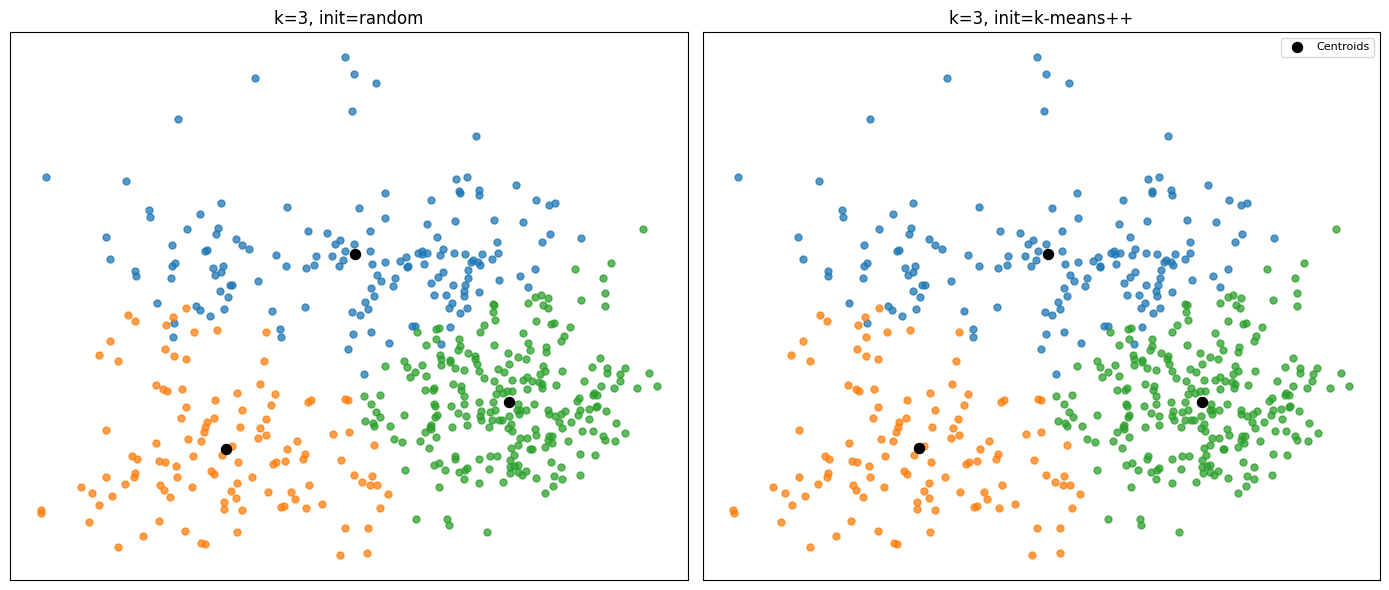

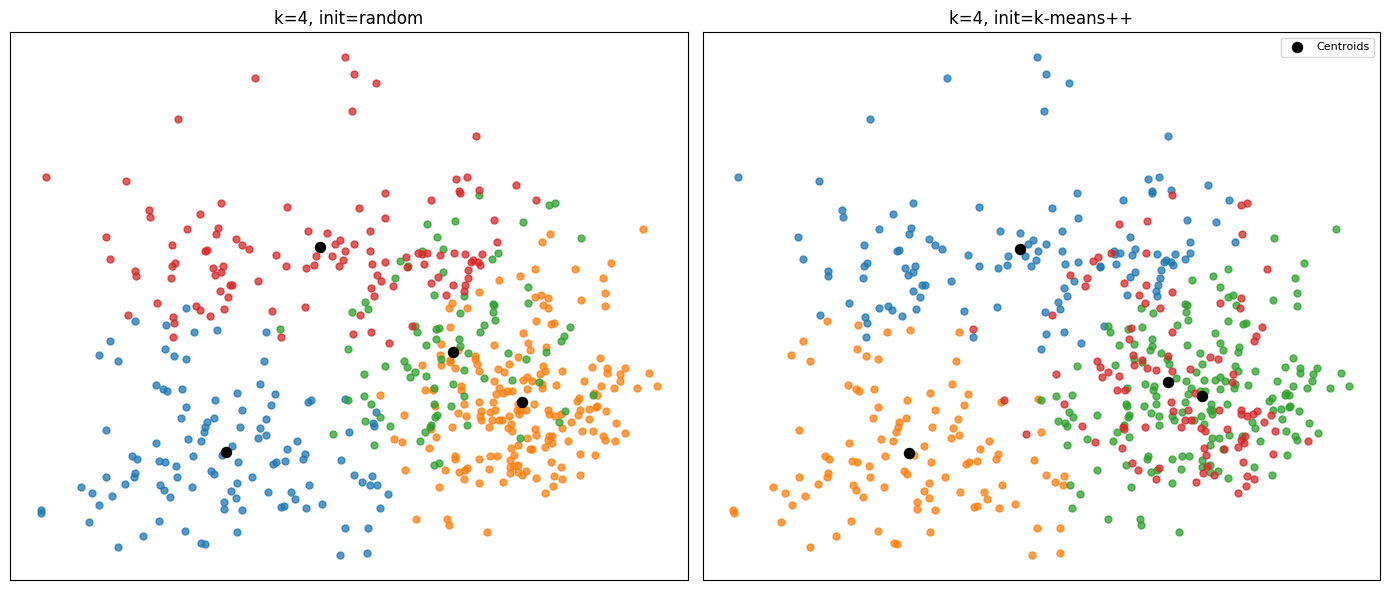

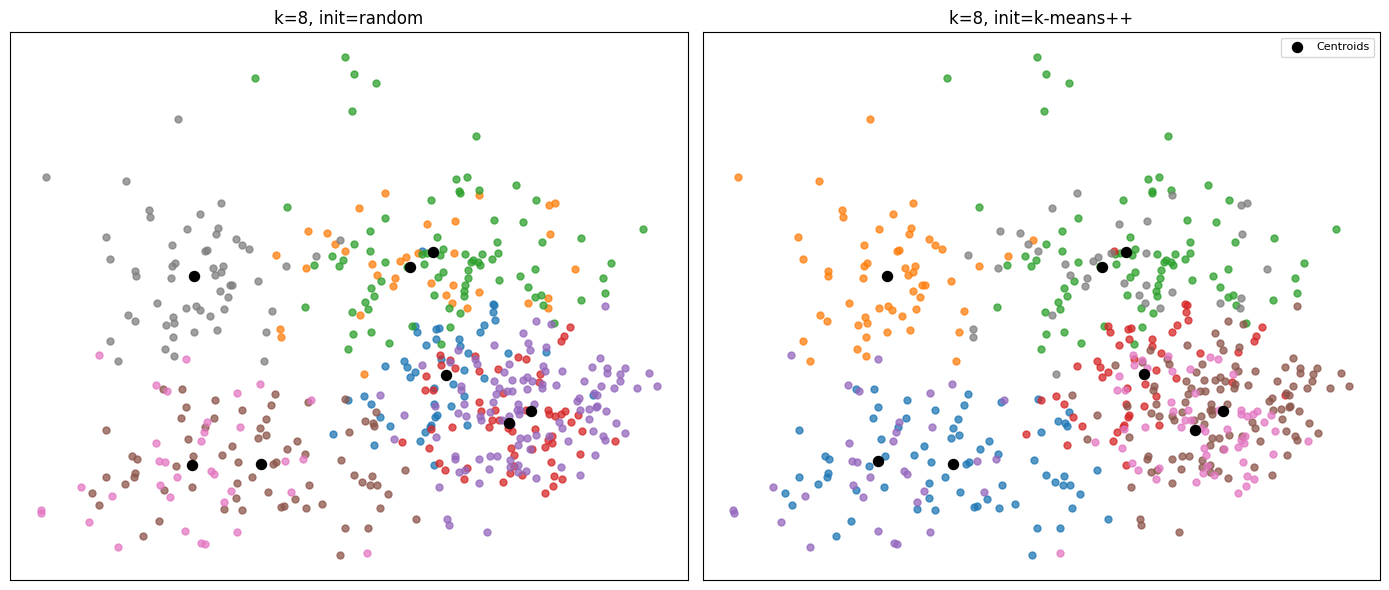

In [19]:
# Implement clustering algorithm here: Method 1 (K-means): Manual without any parameter tuning
# Inititilze K and setup K-means (scikit learn) 
k_values = [3, 4, 8]
init_opts = ['random', 'k-means++']

pca= PCA(n_components=2, random_state=RANDOM_SEED).fit(X)
pca_t = pca.transform(X)

# Use a fixed sample for cleaner visuals while keeping comparisons fair
sample  = np.random.default_rng(RANDOM_SEED)
sample_n = min(500, pca_t.shape[0])
sample_idx = sample.choice(pca_t.shape[0], size=sample_n, replace=False)

# Plots clusters: side-by-side figure per k value
for k in k_values:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
    for ax, init in zip(axes, init_opts):
        km = KMeans(n_clusters=k, init=init, random_state=RANDOM_SEED, n_init=10)
        labels = km.fit_predict(X)
        cents = pca.transform(km.cluster_centers_)
        for c in range(k):
            m = (labels == c)
            m_sample = m & np.isin(np.arange(len(labels)), sample_idx)
            ax.scatter(*pca_t[m_sample].T, s=25, alpha=0.75)
        ax.scatter(*cents.T, s=52, marker='o', c='black', zorder=6, label='Centroids')
        ax.set_title(f'k={k}, init={init}', fontsize=12)
        ax.set_xticks([])
        ax.set_yticks([])
    axes[1].legend(loc='upper right', fontsize=8)
    plt.tight_layout()
    plt.show()

### Method 1: Discussion

From the K-Means plots, `k=3` looks the cleanest and most interpretable, while `k=4` is a reasonable only for K-Means. `k=8` appears very over-segmented.

The K-Means clusters are somewhat usable for summarising broad daily patterns, but they are not strongly separated. Meaning that they are therefore likely most useful for interpretation, and not as strong evidence of naturally distinct clusters.

### Method 2: DBSCAN

#### Feature engineering

In [20]:
# Select base features
features = ['temp', 'windspeed', 'workingday', 'casual', 'registered']

# Log transform count variables to reduce skewness
data_day['casual_log'] = np.log1p(data_day['casual'])
data_day['registered_log'] = np.log1p(data_day['registered'])

# Construct the feature matrix with transformed counts
X = data_day[['temp', 'windspeed', 'workingday', 'casual_log', 'registered_log']]

# Standardize features so each contributes equally to distance
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#### Plot the k-distance graph to choose epsilon for DBSCAN

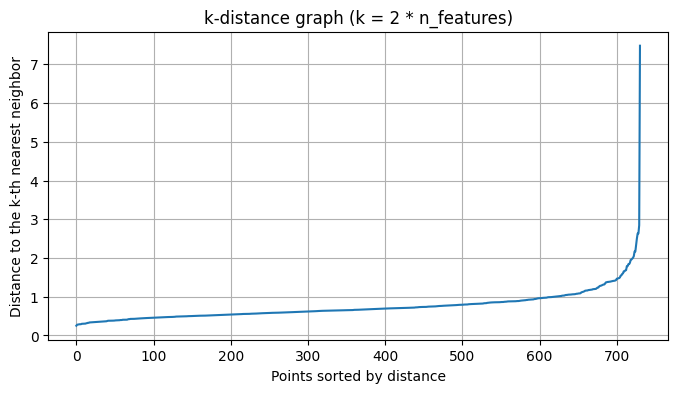

In [22]:
# Plot the k-distance graph to choose eps for DBSCAN
# Set min_samples as twice the number of features
min_samples_estimate = 2 * X.shape[1]

neighbors = NearestNeighbors(n_neighbors=int(min_samples_estimate))
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, int(min_samples_estimate) - 1])

plt.figure(figsize=(8, 4))
plt.plot(distances)
plt.title('k-distance graph (k = 2 * n_features)')
plt.xlabel('Points sorted by distance')
plt.ylabel('Distance to the k-th nearest neighbor')
plt.grid(True)
plt.show()

# After plotting, inspect the curve for an elbow point.  This value of distance
# will be used as the eps parameter for DBSCAN.

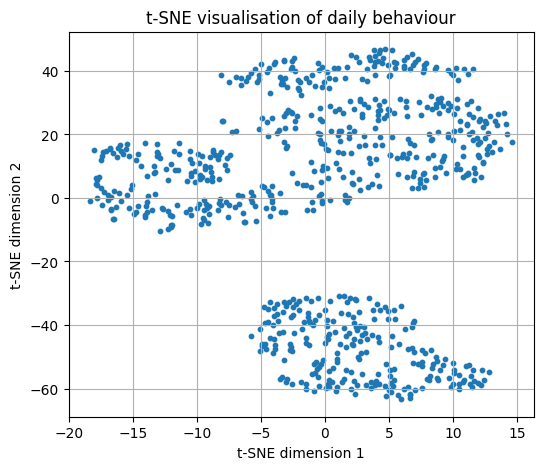

In [24]:
# Perform t-SNE to visualise potential clusters
# Use a moderate perplexity.  t-SNE is stochastic; random_state ensures reproducibility.
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(6, 5))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], s=10)
plt.title('t-SNE visualisation of daily behaviour')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.grid(True)
plt.show()

# Look for visually separated clusters.  If distinct clouds appear, DBSCAN is likely appropriate.

#### Choosing DBSCAN parameters

The DBSCAN algorithm requires two key parameters:

- **`eps` (epsilon)** – defines the radius of the neighborhood for clustering.  Use the elbow point from the k-distance graph as a guideline for choosing `eps`.The epsilon parameter was selected from the k-distance graph by identifying the elbow point at approximately 1.4, which represents the transition from dense regions to sparse regions.
- **`min_samples`** – minimum number of points required to form a dense region.  A common heuristic is to set `min_samples` to twice the number of features; in this case, that is 10.  You may adjust it based on domain knowledge.

After examining the k-distance plot, set `eps` in the next cell and run the clustering.  Note that changing `eps` or `min_samples` will affect the number and composition of clusters.


In [25]:
# Apply DBSCAN clustering
from sklearn.cluster import DBSCAN

# TODO: Replace the value below with your chosen eps from the k-distance graph.
eps_value = 1.4  # <-- Set your chosen epsilon here
min_samples_value = int(2 * X.shape[1])  # default to 2 * n_features

# Fit DBSCAN
dbscan = DBSCAN(eps=eps_value, min_samples=min_samples_value)
labels = dbscan.fit_predict(X_scaled)

# Assign cluster labels back to the data
data_day['cluster'] = labels

# Summarise cluster sizes (including noise labelled as -1)
cluster_counts = data_day['cluster'].value_counts()
print('Cluster counts (including noise):')
print(cluster_counts)

# Compute mean values of key variables per cluster
summary = data_day.groupby('cluster')[['temp', 'windspeed', 'casual', 'registered']].mean()
print('Cluster summaries (mean values):')
print(summary)

Cluster counts (including noise):
cluster
 1    494
 0    226
-1     11
Name: count, dtype: int64
Cluster summaries (mean values):
             temp  windspeed       casual   registered
cluster                                               
-1       0.285725   0.301096   107.727273   686.000000
 0       0.484783   0.188015  1397.300885  3003.323009
 1       0.504904   0.189154   613.445344  4020.981781


#### Method 2: Discussion

DBSCAN identified a small set of anomalous days characterized by low temperature and low rental activity.

**Cluster 0 (226 days)**
temp → moderate (0.48)

casual → very high (1397)

registered → moderate

**This cluster represents leisure-oriented usage patterns.**


**Cluster 1 (494 days)**
temp → similar (0.50)

casual → moderate

registered → very high (4020)

**This cluster corresponds to regular commuter-driven demand.**

## 3. Module 2 — Graph-Based Analysis

In [12]:
import networkx as nx

# Build graph
G = nx.Graph()

## 4. Module 3 — Pattern / Text Mining

In [13]:
# Pattern mining implementation
patterns = None

## 5. Final Synthesis and Reflection

- Key insights:
- Limitations:
- Revisions after feedback:
